<a href="https://colab.research.google.com/github/Jerefilms/DEEP-LEARNING/blob/main/trabajo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SAMUEL DAVID CELIS JEREMICHE
Inteligencia artificial

Parte 1: implementación d funciones de activacion y derivadas



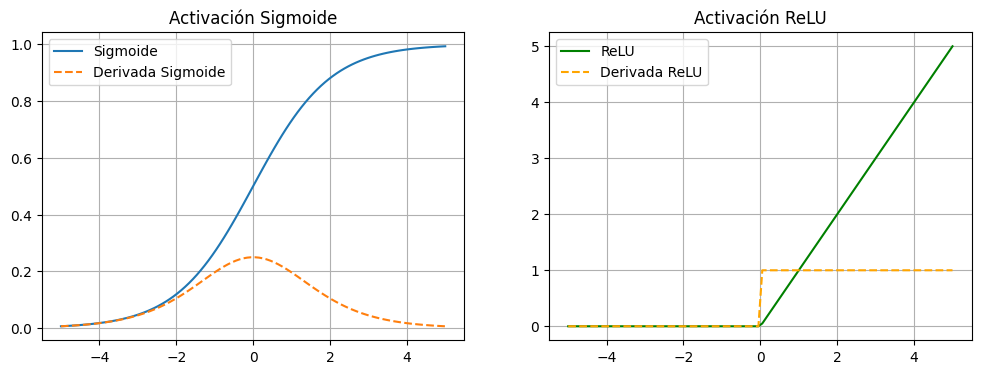

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# La que vemos ahora acontinuacion es la función sigmoide y su derivada
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# Ahora se mostrara la función ReLU y su derivada
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

# Ahora se mostraran las graficas explicativas
z = np.linspace(-5, 5, 100)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(z, sigmoid(z), label='Sigmoide')
ax[0].plot(z, sigmoid_derivative(z), label='Derivada Sigmoide', linestyle='--')
ax[0].set_title('Activación Sigmoide')
ax[0].grid(True); ax[0].legend()

ax[1].plot(z, relu(z), label='ReLU', color='green')
ax[1].plot(z, relu_derivative(z), label='Derivada ReLU', color='orange', linestyle='--')
ax[1].set_title('Activación ReLU')
ax[1].grid(True); ax[1].legend()

plt.show()

#el sigmoide comprime cualquier valor continua entre el 0 y 1,
#Su derivada alcanza un valor máximo de $0.25$
#el relu devuelve 0 para entradas negativas y la misma entrada para valores positivos

parte 2: perceptrón simple, red de una capa y red multicapa con backpropagation

A continuacion implementamos una red multicapa desde cero capaz de aprender la función lógica XOR


In [3]:
import numpy as np

class MultilayerPerceptron:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):

        # aca vamos a inicializar pesos y sesgos
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.zeros((1, output_size))
        self.lr = learning_rate

    def forward(self, X):
        # se muestra la propagación hacia adelante
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = relu(self.Z1) # una capa oculta con ReLU
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = sigmoid(self.Z2) # esta es la capa de salida con sigmoide
        return self.A2

    def backward(self, X, y):
        # se crea el algoritmo de Backpropagation
        m = X.shape[0]

        # Mostramos el error en capa de salida
        dZ2 = self.A2 - y
        dW2 = (1 / m) * np.dot(self.A1.T, dZ2)
        db2 = (1 / m) * np.sum(dZ2, axis=0, keepdims=True)

        # Esta es la propagación del error a la capa oculta
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * relu_derivative(self.Z1)
        dW1 = (1 / m) * np.dot(X.T, dZ1)
        db1 = (1 / m) * np.sum(dZ1, axis=0, keepdims=True)

        # Actualización de Parametros
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=5000):
        for epoch in range(epochs):
            self.forward(X)
            self.backward(X, y)

# Va,os a entrenar la compuerta XOr
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

mlp = MultilayerPerceptron(input_size=2, hidden_size=4, output_size=1, learning_rate=0.5)
mlp.train(X, y, epochs=5000)

print("Predicciones finales para XOR:")
for i in range(len(X)):
    pred = mlp.forward(X[i:i+1])
    print(f"Entrada: {X[i]} -> Predicción: {pred[0][0]:.4f} (Clase: {int(pred > 0.5)})")

Predicciones finales para XOR:
Entrada: [0 0] -> Predicción: 0.0010 (Clase: 0)
Entrada: [0 1] -> Predicción: 0.9998 (Clase: 1)
Entrada: [1 0] -> Predicción: 0.9998 (Clase: 1)
Entrada: [1 1] -> Predicción: 0.0010 (Clase: 0)


/tmp/ipykernel_1100/1160232184.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Entrada: {X[i]} -> Predicción: {pred[0][0]:.4f} (Clase: {int(pred > 0.5)})")


Forward Pass: Se calculan las combinaciones lineales

Backpropagation: Aplica la regla de la cadena para calcular las derivadas parciales, y la
Actualizacion de los parámetros ajustan su valor en dirección opuesta al gradiente multiplicado por la tasa de aprendizaje

PARTE 3: Clasificación Binaria
Generamos un conjunto de datos sintético no lineal

In [4]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ACA GENERAMOS EL DATA SET
X_data, y_data = make_moons(n_samples=1000, noise=0.2, random_state=42)
y_data = y_data.reshape(-1, 1)

# SE MUESTRA EL ESCALADO Y LA DIVISIÓN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_data, test_size=0.2, random_state=42)

# SE ENTRENA LA NEU
binary_mlp = MultilayerPerceptron(input_size=2, hidden_size=8, output_size=1, learning_rate=0.1)
binary_mlp.train(X_train, y_train, epochs=2000)

#EVALUACION
test_preds = binary_mlp.forward(X_test)
binary_preds = (test_preds >= 0.5).astype(int)
accuracy = np.mean(binary_preds == y_test)
print(f"Precisión en el conjunto de prueba: {accuracy * 100:.2f}%")

Precisión en el conjunto de prueba: 97.50%


Se normalizan los datos con StandardScaler para acelerar la convergencia del descenso de gradiente.

Se entrena el perceptrón multicapa personalizado y se evalúa el umbral $0.5$


PARTE 4:Clasificación Multiclase con TensorFlow + Keras
Construimos una red neuronal completamente conectada

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Se realiza la carga y preprocesamiento de datos
mnist = tf.keras.datasets.mnist
(X_train_tf, y_train_tf), (X_test_tf, y_test_tf) = mnist.load_data()

# Esta es la normalización 0, 255 - 0.0, 1.0 y aplanado 28x28  784
X_train_tf = X_train_tf.reshape(-1, 784) / 255.0
X_test_tf = X_test_tf.reshape(-1, 784) / 255.0

# se realiza la definición del modelo
model_tf = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # cclasificación de 10 clases
])

# Compilación de los das
model_tf.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento de la neu
history_tf = model_tf.fit(
    X_train_tf, y_train_tf,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

# Evaluación de los datos
test_loss, test_acc = model_tf.evaluate(X_test_tf, y_test_tf)
print(f"\n[TensorFlow/Keras] Exactitud en test: {test_acc * 100:.2f}%")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9132 - loss: 0.3023 - val_accuracy: 0.9612 - val_loss: 0.1284
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9633 - loss: 0.1236 - val_accuracy: 0.9707 - val_loss: 0.1029
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9745 - loss: 0.0852 - val_accuracy: 0.9745 - val_loss: 0.0838
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9806 - loss: 0.0624 - val_accuracy: 0.9742 - val_loss: 0.0860
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9852 - loss: 0.0482 - val_accuracy: 0.9748 - val_loss: 0.0937
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9874 - loss: 0.0390 - val_accuracy: 0.9772 - val_loss: 0.0807
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9898 - loss: 0.0322 - val_accuracy: 0.9797 - val_loss: 0.0738
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9913 - loss: 0.0262 - val_accuracy: 0.

Flatten Implicito: Aplanamos las imágenes de dimensiones 28 times 28 pixeles a un vector unidimensional de 784 elementos.

Softmax: La capa final contiene $10$ neuronas

PARTE 5 Clasificación Multiclase con PyTorch
Replicamos la misma arquitectura multicapa en PyTorch

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# SE REALIZA LAS TRANSFORMACIONES Y CARGAS DE DATA
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# ESTA ES LA RED NEURONAL
class PyTorchMLP(nn.Module):
    def __init__(self):
        super(PyTorchMLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28) #SE APLANA LA IMAGEN EN ETA LINEA DE CODIGO
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x) #SE DEVUELVE EL LOGIT
        return x

model_pt = PyTorchMLP()
criterion = nn.CrossEntropyLoss() # TIENE SOFTMAX INDIRECTAMENTE
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

#CREAMOS UN BUCLE DE ENTRENAMIENTO
epochs = 5
model_pt.train()
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()           #SE LIMPIA LOS GRADIENTES
        outputs = model_pt(images)
        loss = criterion(outputs, labels) # SE CALCULA CUANTO SE PERDIO
        loss.backward()                #
        optimizer.step()               #SE ACTUALIZA EL PESO
        running_loss += loss.item()

    print(f"Época {epoch+1}/{epochs} - Pérdida: {running_loss/len(train_loader):.4f}")

# SE EVALUA EL MODELO
model_pt.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model_pt(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\n[PyTorch] Exactitud en el conjunto de prueba: {(100 * correct / total):.2f}%")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.34MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.61MB/s]


Época 1/5 - Pérdida: 0.2760
Época 2/5 - Pérdida: 0.1120
Época 3/5 - Pérdida: 0.0783
Época 4/5 - Pérdida: 0.0605
Época 5/5 - Pérdida: 0.0475

[PyTorch] Exactitud en el conjunto de prueba: 97.56%
